# Cognifyz Data Science Internship
## Task 2: Descriptive Analysis

### Objective

Perform descriptive analysis on the restaurant dataset by:

- Calculating descriptive statistics
- Analyzing the distribution of Country Code
- Analyzing the distribution of City
- Analyzing the distribution of Cuisines
- Identifying the top cuisines
- Identifying the top cities

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## Load the dataset

In [ ]:
df = pd.read_csv("Cleaned_Dataset.csv")

print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (9551, 21)


In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Descriptive statistics


In [7]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [9]:
num_columns = [
    "Aggregate rating",
    "Votes",
    "Price range"
]

df[num_columns].describe()

,Aggregate rating,Votes,Price range
count,9551.000000,9551.000000,9551.000000
mean,2.666370,156.909748,1.804837
std,1.516378,430.169145,0.905609
min,0.000000,0.000000,1.000000
25%,2.500000,5.000000,1.000000
50%,3.200000,31.000000,2.000000
75%,3.700000,131.000000,2.000000
max,4.900000,10934.000000,4.000000


## Analyze Country Code distribution
### Count restaurants by country

In [10]:
country_counts = df["Country Code"].value_counts().sort_index()

print("Restaurant count by Country Code:")
print(country_counts)

Restaurant count by Country Code:
Country Code
1      8652
14       24
30       60
37        4
94       21
148      40
162      22
166      20
184      20
189      60
191      20
208      34
214      60
215      80
216     434
Name: count, dtype: int64


### Calculate percentages

In [11]:
country_percentage = (
    df["Country Code"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Percentage of restaurants by Country Code:")
print(country_percentage.round(2))

Percentage of restaurants by Country Code:
Country Code
1      90.59
14      0.25
30      0.63
37      0.04
94      0.22
148     0.42
162     0.23
166     0.21
184     0.21
189     0.63
191     0.21
208     0.36
214     0.63
215     0.84
216     4.54
Name: proportion, dtype: float64


### Create a chart

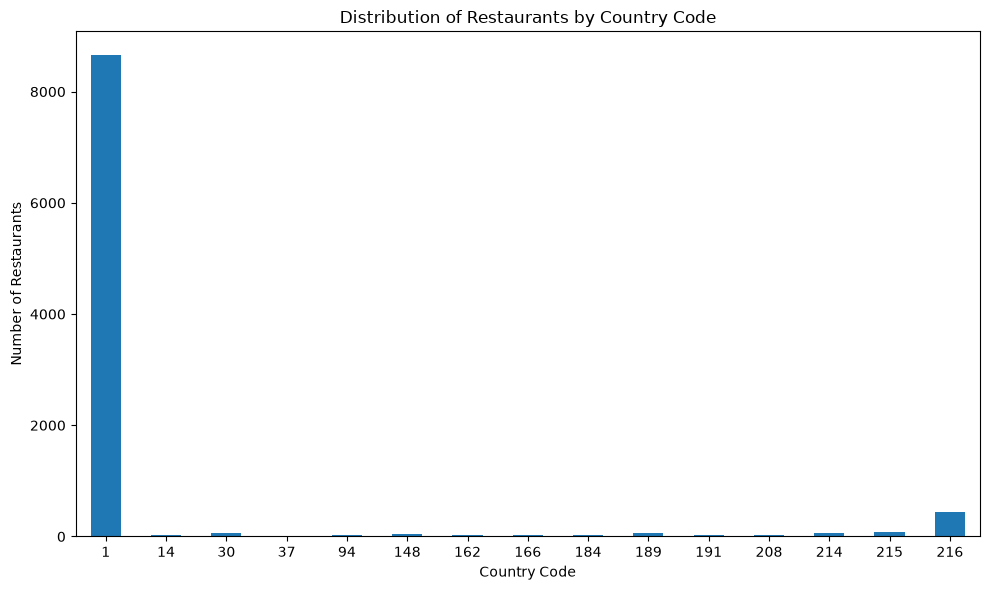

In [12]:
plt.figure(figsize=(10, 6))

country_counts.plot(kind="bar")

plt.title("Distribution of Restaurants by Country Code")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Identify the most represented country

In [13]:
top_country_code = df["Country Code"].value_counts().idxmax()
top_country_count = df["Country Code"].value_counts().max()

print("Most represented Country Code:", top_country_code)
print("Number of restaurants:", top_country_count)

Most represented Country Code: 1
Number of restaurants: 8652


## Analyze City distribution

In [14]:
city_counts = df["City"].value_counts()

print("Top 10 cities by number of restaurants:")
print(city_counts.head(10))

Top 10 cities by number of restaurants:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64


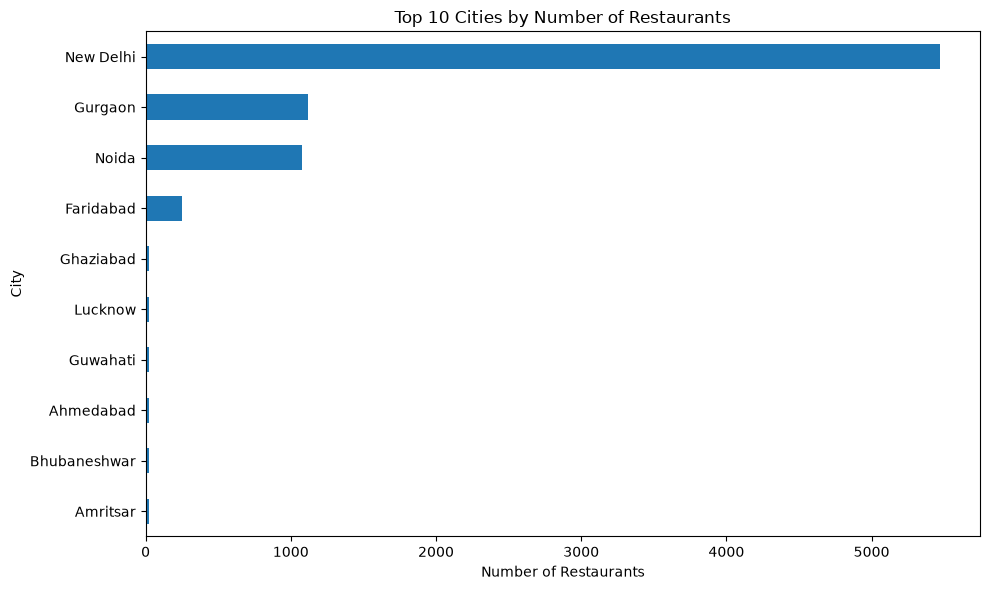

In [15]:
plt.figure(figsize=(10, 6))

city_counts.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [16]:
top_city = city_counts.idxmax()
top_city_count = city_counts.max()

print("Most represented city:", top_city)
print("Number of restaurants:", top_city_count)

Most represented city: New Delhi
Number of restaurants: 5473


### City Analysis - Conclusion

The dataset contains restaurants from many different cities. New Delhi is the most represented city, with 5,473 restaurants. This indicates that the dataset is highly concentrated in New Delhi compared with other cities.

### Analyze Cuisines

In [17]:
cuisine_counts = df["Cuisines"].value_counts()

print("Top 10 cuisines by number of restaurants:")
print(cuisine_counts.head(10))

Top 10 cuisines by number of restaurants:
Cuisines
North Indian                      945
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


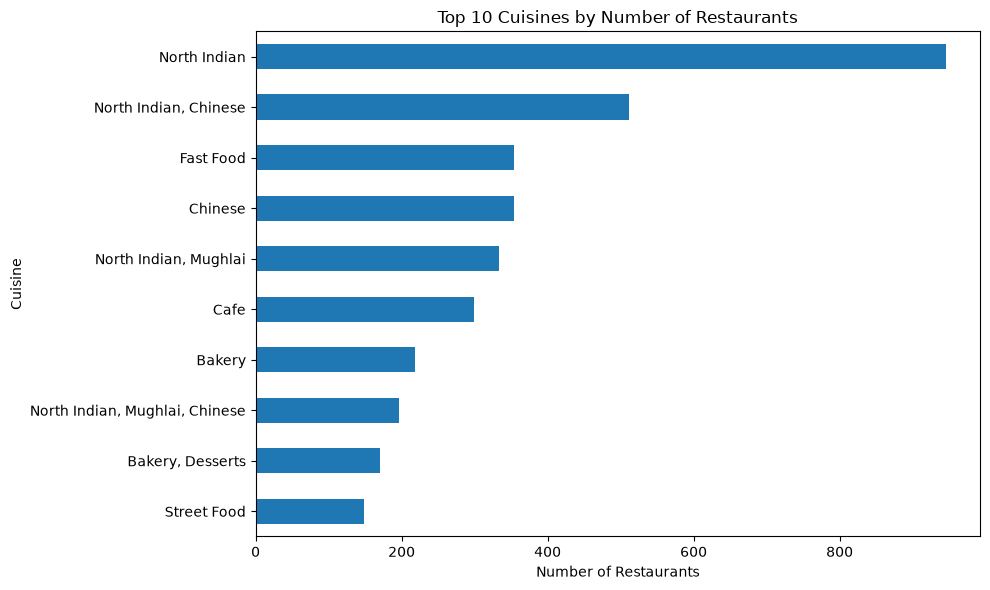

In [18]:
plt.figure(figsize=(10, 6))

cuisine_counts.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Cuisines by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.tight_layout()
plt.show()

In [19]:
top_cuisine = cuisine_counts.idxmax()
top_cuisine_count = cuisine_counts.max()

print("Most represented cuisine:", top_cuisine)
print("Number of restaurants:", top_cuisine_count)

Most represented cuisine: North Indian
Number of restaurants: 945


### Cuisine Analysis - Conclusion

The cuisine distribution shows that North Indian cuisine is the most represented cuisine in the dataset, with 945 restaurants. North Indian, Chinese is the second most common cuisine combination, with 511 restaurants. Other frequently represented categories include Chinese, Fast Food, Mughlai, Cafe, Bakery, and Street Food.

## Overall Descriptive Analysis

### Key Findings

- The dataset contains **9,551 restaurants** across **21 columns**.
- **Country Code 1** is the most represented country code, with **8,652 restaurants**.
- **New Delhi** is the most represented city, with **5,473 restaurants**.
- **North Indian** is the most represented cuisine, with **945 restaurants**.
- Other frequently represented cuisines include North Indian, Chinese, Chinese, Fast Food, Mughlai, Cafe, Bakery, and Street Food.

## Conclusion

The descriptive analysis shows that the restaurant dataset is concentrated in a relatively small number of locations and cuisine categories. Country Code 1 contains the majority of restaurants, while New Delhi is the most represented city. North Indian is the most common cuisine, followed by several popular cuisine combinations and categories.

The descriptive statistics and distribution analysis provide an overall understanding of the structure and characteristics of the restaurant dataset.